# EigenCAM dla RF-DETR (implementacja własna)

Gradient-free saliency na poziomie detekcji; implementacja bez `pytorch-grad-cam`.

**Schemat działania:**

```
forward() z hookiem na C2f.cv2  →  aktywacja [B, C, H, W]
  →  spłaszczenie → [N, C],  centering
  →  SVD → pierwszy komponent główny vh[0]  ∈  R^C
  →  projekcja każdego punktu przestrzennego → mapa H × W
  →  ReLU + normalizacja min-max → interpolacja do orig_hw
```

**Matematyka EigenCAM (arXiv:2008.00299):**
$$\text{features} = A^{(b)} \in \mathbb{R}^{N \times C}, \quad N = H \cdot W$$
$$\text{SVD: } \tilde{A} = U S V^\top \quad \Rightarrow \quad \mathbf{v}_1 = V[0] \in \mathbb{R}^C$$
$$\text{CAM} = \text{ReLU}\bigl(\tilde{A}\,\mathbf{v}_1\bigr) \in \mathbb{R}^N \quad \xrightarrow{\text{reshape}} \quad \mathbb{R}^{H \times W}$$

Implementacja w `src/rfdetr_eigencam.py`.

**Ważna uwaga metodologiczna:** EigenCAM jest **gradient-free** i **nie jest query-specific**.
Ta sama mapa aktywacji jest generowana dla całego obrazu — niezależnie od detekcji.
Do oceny per-detekcja ta sama mapa jest ewaluowana osobno dla każdego bbox.
Interpretuj wyniki ostrożniej niż D-RISE czy attention evidence map.

**Warstwa docelowa:** ta sama `C2f.cv2` z ostatniego etapu `MultiScaleProjector` co GradCAM++.

In [8]:
from pathlib import Path
import os
import sys
import site

def find_repo_root(marker="pyproject.toml", max_depth=10):
    current = Path.cwd().resolve()
    for _ in range(max_depth):
        if (current / marker).exists():
            return current
        current = current.parent
    return None

def prefer_venv_site_packages():
    venv_prefix = str(Path(sys.prefix).resolve())
    venv_sites = [p for p in site.getsitepackages() if p.startswith(venv_prefix)]
    cleaned = [p for p in sys.path if not (p.startswith("/net/software/") and "site-packages" in p)]
    for p in reversed(venv_sites):
        if p in cleaned:
            cleaned.remove(p)
        cleaned.insert(0, p)
    sys.path[:] = cleaned
    cached = sys.modules.get("regex")
    cached_path = getattr(cached, "__file__", "") if cached is not None else ""
    if cached_path.startswith("/net/software/"):
        for name in list(sys.modules.keys()):
            if name == "regex" or name.startswith("regex."):
                del sys.modules[name]

REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = Path("/net/tscratch/people/plgbmruszaj/dermatoscopy_ai")

RFD_XAI_ROOT = REPO_ROOT / "dermato_ai" / "rfdetr-xai"
os.chdir(RFD_XAI_ROOT)
sys.path.insert(0, str(RFD_XAI_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT))
prefer_venv_site_packages()

from dermato_ai.coco.dataset_manager import COCODatasetManager

DATA_ZIP_DIR = REPO_ROOT / "data" / "coco_images_zip"
manager = COCODatasetManager.from_archive(directory=DATA_ZIP_DIR, archive_pattern="*.zip")
dataset_dir = Path(manager.json_path).parent
dedup_coco_json = dataset_dir / "result_dedup_for_eigencam.json"
manager.save(str(dedup_coco_json))

COCO_JSON = str(dedup_coco_json)
IMAGES_DIR = str(dataset_dir / "images")

CHECKPOINT = "/net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth"
OUTPUT_DIR = RFD_XAI_ROOT / "wyniki" / "rfdetr_eigencam"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Python:", sys.executable)
print("✓ COCO JSON:", COCO_JSON)
print("✓ Images:", IMAGES_DIR)
print("✓ Checkpoint:", CHECKPOINT)
print("✓ Output dir:", OUTPUT_DIR)

INFO: Found newest archive: project-5-at-2026-05-07-11-56-9b7fa76c.zip
INFO: Unpacking project-5-at-2026-05-07-11-56-9b7fa76c.zip to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted


INFO: Extraction complete
INFO: Found result.json at: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loading COCO dataset from /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result.json
INFO: Loaded 314 images, 1299 annotations
INFO: Collapsed duplicate image passes: removed 97 image entries and 0 annotations
INFO: Valid COCO structure: 217 images, 1299 annotations, 10 categories
INFO: Fixed 217 image paths
INFO: Saved dataset to /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_eigencam.json


✓ Python: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/.venv/bin/python
✓ COCO JSON: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/result_dedup_for_eigencam.json
✓ Images: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/data/coco_images_zip/extracted/images
✓ Checkpoint: /net/tscratch/people/plgbmruszaj/rfdetr_all_data_results_yellow_large_20260507_150528/rfdetr_large_best_2573873/checkpoints/checkpoint_best_ema.pth
✓ Output dir: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_eigencam


## Konfiguracja

In [9]:
THRESHOLD      = 0.25  # próg detekcji dla predict()
MIN_CONFIDENCE = 0.5   # pomiń detekcje poniżej tego confidence przy agregacji metryk
MIN_MATCH_IOU  = 0.3   # minimalny IoU query↔detection; niższy → skip
CLASS_AWARE    = True  # wymagaj zgodności klasy przy dopasowaniu query
CAM_ALPHA      = 0.45  # przezroczystość overlay

# None → domyślna warstwa C2f.cv2 (ta sama co GradCAM++); albo pełna nazwa z inspect_candidate_cam_layers
TARGET_LAYER_NAME = None

# Sweep warstw (sekcja poniżej) — ustaw True, by wykonać
RUN_LAYER_SWEEP = False
# Nazwy warstw do sweepu (wypełnij z inspect_candidate_cam_layers poniżej)
CANDIDATE_LAYER_NAMES: list[str] = []

# Indeks obrazu w posortowanej liście (zmień, by zobaczyć inny obraz)
IMAGE_IDX = 0

## Ładowanie modelu i obrazu

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from rfdetr_load import load_rfdetr
from rfdetr_gradcampp_custom import (
    DEFAULT_CAM_TARGET_LAYER_NAME,
    default_target_layer_name,
    get_module_by_name,
    inspect_candidate_cam_layers,
    match_detection_to_query,
    preprocess_for_gradcampp,
    resolve_rfdetr_device,
)
from rfdetr_eigencam import (
    ActivationHook,
    compute_eigencam_from_activation,
    compute_rfdetr_eigencam,
    eigencam_layer_sweep,
    make_eigencam_figure,
    save_eigencam_result,
)
from xai_metrics import (
    pointing_game_hit,
    energy_fraction_inside_bbox,
    energy_enrichment_inside_bbox,
)

try:
    from IPython.display import display
except ImportError:
    display = print

model = load_rfdetr("large", CHECKPOINT)

all_images = sorted(Path(IMAGES_DIR).glob("*"))
image_path = all_images[IMAGE_IDX]
pil_img = Image.open(image_path).convert("RGB")
image_rgb = np.array(pil_img)

print(f"✓ Model załadowany")
print(f"✓ Obraz: {image_path.name}  ({pil_img.width}×{pil_img.height} px)")

[2026-05-07 22:28:18] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-07 22:28:18] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-07 22:28:19] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


✓ Model załadowany
✓ Obraz: 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg  (1920×1080 px)


## Weryfikacja warstwy docelowej

Ta sama warstwa co GradCAM++: `C2f.cv2` z ostatniego etapu `MultiScaleProjector`.

> **Uwaga dot. device:** `resolve_rfdetr_device` pobiera urządzenie z
> `next(inner.parameters()).device` — jedyne wiarygodne źródło (backbone DINOv2
> może być na CPU mimo że `rfdetr_api.model.device` wskazuje CUDA).

In [11]:
import torch

inner = model.model.model
_layer_name = default_target_layer_name(inner)
target_layer = get_module_by_name(inner, _layer_name)
device = resolve_rfdetr_device(model)
batch, orig_hw, input_hw = preprocess_for_gradcampp(model, pil_img)

print("✓ Warstwa docelowa:", target_layer.__class__.__name__)
print(f"✓ Urządzenie modelu (z parametrów): {device}")
print(f"✓ Batch device: {batch.device}  dtype: {batch.dtype}")
print(f"✓ orig_hw={orig_hw}  input_hw={input_hw}")

# Probe: kształt aktywacji z warstwy docelowej (bez grad)
captured = []

def _probe_hook(module, inputs, output):
    t = output if isinstance(output, torch.Tensor) else (output[0] if isinstance(output, (list, tuple)) else None)
    if t is not None:
        captured.append(tuple(t.shape))

handle = target_layer.register_forward_hook(_probe_hook)
try:
    with torch.no_grad():
        _ = inner(batch)
finally:
    handle.remove()

if captured:
    print(f"✓ Kształt aktywacji warstwy: {captured[0]}")
else:
    print("⚠ Hook nie przechwycił aktywacji")

✓ Warstwa docelowa: ConvX
✓ Urządzenie modelu (z parametrów): cpu
✓ Batch device: cpu  dtype: torch.float32
✓ orig_hw=(1080, 1920)  input_hw=(704, 704)
✓ Kształt aktywacji warstwy: (1, 256, 44, 44)


### Kandydaci warstw CAM (do sweepu)

Uruchom raz: lista modułów z wyjściem 3D/4D pasujących do słów kluczowych. Domyślna warstwa EigenCAM / GradCAM++:

`default_target_layer_name(inner)` — wklej wybrane nazwy do `CANDIDATE_LAYER_NAMES` w sekcji sweep.

In [12]:
print("Kanoniczna warstwa CAM (baseline):", DEFAULT_CAM_TARGET_LAYER_NAME)
DEFAULT_CAM_LAYER_NAME = default_target_layer_name(inner)
print("Rozwiązana domyślna nazwa w tym modelu:", DEFAULT_CAM_LAYER_NAME)

candidates = inspect_candidate_cam_layers(model, pil_img)
print(f"\nLiczba kandydatów 4D: {len(candidates)}\n")
for name, cls_name, shape in sorted(candidates, key=lambda x: x[0])[:80]:
    print(f"  {name:85s} | {cls_name:28s} | {shape}")
if len(candidates) > 80:
    print(f"  ... i {len(candidates) - 80} więcej")

Domyślna warstwa (EigenCAM / GradCAM++): backbone.0.projector.stages.0.0.cv2

Znaleziono 292 hooków (możliwe duplikaty nazw — pierwszy forward):

  backbone                                                                              | Joiner                       | (1, 256, 44, 44)
  backbone.0.encoder                                                                    | DinoV2                       | (1, 384, 44, 44)
  backbone.0.encoder.encoder                                                            | WindowedDinov2WithRegistersBackbone | (1, 384, 44, 44)
  backbone.0.encoder.encoder.embeddings                                                 | WindowedDinov2WithRegistersEmbeddings | (4, 485, 384)
  backbone.0.encoder.encoder.embeddings.dropout                                         | Dropout                      | (4, 485, 384)
  backbone.0.encoder.encoder.embeddings.patch_embeddings                                | Dinov2WithRegistersPatchEmbeddings | (1, 1936, 384)
  backbone.0

## Detekcje z predict()

In [13]:
det = model.predict(pil_img, threshold=THRESHOLD)

if det is None or len(det) == 0:
    print(f"⚠ Brak detekcji (threshold={THRESHOLD}). Zmień IMAGE_IDX lub obniż THRESHOLD.")
else:
    print(f"✓ Znaleziono {len(det)} detekcji:")
    for i in range(len(det)):
        cls_id = int(det.class_id[i])
        conf   = float(det.confidence[i])
        box    = [round(v, 1) for v in det.xyxy[i].tolist()]
        print(f"  det={i}  class_id={cls_id}  conf={conf:.4f}  box={box}")

[2026-05-07 22:28:24] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


✓ Znaleziono 4 detekcji:
  det=0  class_id=0  conf=0.8513  box=[861.7, 713.1, 922.8, 812.9]
  det=1  class_id=0  conf=0.8155  box=[554.0, 488.9, 625.1, 652.4]
  det=2  class_id=0  conf=0.7669  box=[679.9, 821.2, 793.5, 875.2]
  det=3  class_id=0  conf=0.7176  box=[496.8, 800.7, 539.1, 896.9]


## EigenCAM dla pierwszej detekcji

EigenCAM oblicza **jedną globalną mapę** dla obrazu i wybranej warstwy —
bez backward, bez target score. Poniżej dopasowujemy query do detekcji
przez IoU (tak jak GradCAM++), by zachować spójne metadane.

✓ EigenCAM shape: (1080, 1920)  min=0.0000  max=1.0000
✓ Użyta warstwa: backbone.0.projector.stages.0.0.cv2

Match info:
{
  "det_idx": 0,
  "query_id": 0,
  "matched_iou": 0.9993119239807129,
  "pred_class_id": 0,
  "logit_class_id": 0,
  "pred_confidence": 0.8512956500053406,
  "raw_query_class_score": 0.8522352576255798,
  "box_orig_xyxy": [
    861.7444458007812,
    713.0776977539062,
    922.7802734375,
    812.891357421875
  ],
  "box_input_xyxy": [
    315.97296142578125,
    464.8210144042969,
    338.3527526855469,
    529.884765625
  ]
}

Pointing game: False  |  Energy fraction: 0.0001  |  Quality: failed


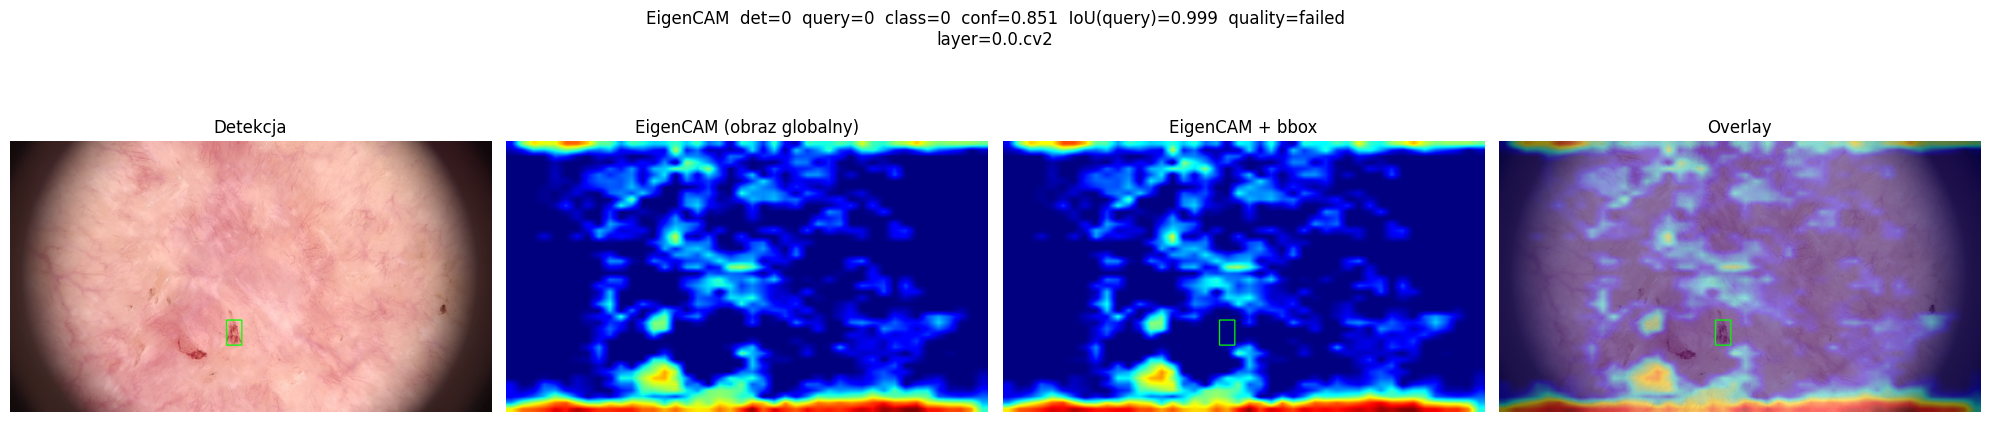

In [14]:
DET_IDX = 0  # indeks detekcji (zmień na dowolny z listy wyżej)

# 1. Globalna mapa EigenCAM dla obrazu
cam, orig_hw_cam, input_hw_cam, layer_name_used = compute_rfdetr_eigencam(
    rfdetr_api=model,
    pil_image=pil_img,
    target_layer_name=TARGET_LAYER_NAME,
)
print(f"✓ EigenCAM shape: {cam.shape}  min={cam.min():.4f}  max={cam.max():.4f}")
print(f"✓ Użyta warstwa: {layer_name_used}")

# 2. Raw forward do query matching — świeży batch na aktualnym urządzeniu modelu
# (model.predict() może przenieść wagi na CUDA; stary `batch` z komórki weryfikacyjnej
#  mógłby być na innym urządzeniu)
batch_fwd, _, _ = preprocess_for_gradcampp(model, pil_img)
with torch.no_grad():
    raw_out = inner(batch_fwd)
    if isinstance(raw_out, tuple):
        raw_out = {"pred_logits": raw_out[1], "pred_boxes": raw_out[0]}

# 3. Dopasowanie query do wybranej detekcji
match = match_detection_to_query(
    pred_detections=det,
    det_idx=DET_IDX,
    raw_outputs=raw_out,
    orig_hw=orig_hw_cam,
    input_hw=input_hw_cam,
    class_aware=CLASS_AWARE,
)
print("\nMatch info:")
print(json.dumps(match, indent=2))

# 4. Metryki
box_xyxy = tuple(match["box_orig_xyxy"])
hit  = pointing_game_hit(cam, box_xyxy)
ef   = energy_fraction_inside_bbox(cam, box_xyxy)
ee   = energy_enrichment_inside_bbox(cam, box_xyxy)
qual = cam_quality_status(hit, ef)

# energy_enrichment: ≈1 → losowa, >1 → mapa preferuje box, <1 → mapa omija box
print(f"\nPointing game:      {hit}")
print(f"Energy fraction:    {ef:.4f}")
print(f"Energy enrichment:  {ee:.4f}  (EF / box_area_frac; baseline=1.0)")
print(f"Quality:            {qual}")

# 5. Wizualizacja
fig = make_eigencam_figure(
    image_rgb=image_rgb,
    cam=cam,
    match=match,
    class_name=str(match["pred_class_id"]),
    layer_name=layer_name_used,
    cam_quality=qual,
)
plt.show()

## Batch: EigenCAM dla wszystkich detekcji na bieżącym obrazie

Jedna mapa EigenCAM → oceniana per-bbox; wyniki zapisywane do `OUTPUT_DIR`.

In [15]:
# Oblicz mapę raz dla całego obrazu
cam_global, orig_hw_g, input_hw_g, layer_name_g = compute_rfdetr_eigencam(
    rfdetr_api=model,
    pil_image=pil_img,
    target_layer_name=TARGET_LAYER_NAME,
)

# Świeży batch — model po predict() może być na innym urządzeniu niż stary `batch`
batch_g, _, _ = preprocess_for_gradcampp(model, pil_img)
with torch.no_grad():
    raw_out_g = inner(batch_g)
    if isinstance(raw_out_g, tuple):
        raw_out_g = {"pred_logits": raw_out_g[1], "pred_boxes": raw_out_g[0]}

rows = []

for det_idx in range(len(det)):
    try:
        match_i = match_detection_to_query(
            pred_detections=det,
            det_idx=det_idx,
            raw_outputs=raw_out_g,
            orig_hw=orig_hw_g,
            input_hw=input_hw_g,
            class_aware=CLASS_AWARE,
        )
        if match_i["matched_iou"] < MIN_MATCH_IOU:
            raise RuntimeError(
                f"matched_iou={match_i['matched_iou']:.3f} < MIN_MATCH_IOU={MIN_MATCH_IOU}"
            )
        if match_i["pred_confidence"] < MIN_CONFIDENCE:
            raise RuntimeError(
                f"conf={match_i['pred_confidence']:.3f} < MIN_CONFIDENCE={MIN_CONFIDENCE}"
            )

        box_i    = tuple(match_i["box_orig_xyxy"])
        hit_i    = pointing_game_hit(cam_global, box_i)
        ef_i     = energy_fraction_inside_bbox(cam_global, box_i)
        ee_i     = energy_enrichment_inside_bbox(cam_global, box_i)
        qual_i   = cam_quality_status(hit_i, ef_i)
        stem_i   = f"eigencam_img{IMAGE_IDX}_det{det_idx}_q{match_i['query_id']}"

        save_eigencam_result(
            image_rgb=image_rgb,
            cam=cam_global,
            match=match_i,
            class_name=str(match_i["pred_class_id"]),
            layer_name=layer_name_g,
            out_dir=OUTPUT_DIR,
            stem=stem_i,
            cam_quality=qual_i,
            extra_meta={
                "threshold": THRESHOLD,
                "min_confidence": MIN_CONFIDENCE,
                "min_match_iou": MIN_MATCH_IOU,
                "image": image_path.name,
                "cam_quality": qual_i,
            },
        )

        rows.append({
            "det_idx"            : det_idx,
            "query_id"           : match_i["query_id"],
            "class_id"           : match_i["pred_class_id"],
            "conf"               : round(match_i["pred_confidence"], 4),
            "matched_iou"        : round(match_i["matched_iou"], 4),
            "query_cls_score"    : round(match_i["raw_query_class_score"], 4),
            "pointing_game"      : int(hit_i),
            "energy_fraction"    : round(ef_i, 4),
            "energy_enrichment"  : round(ee_i, 4),
            "cam_quality"        : qual_i,
            "status"             : "ok",
        })
        print(
            f"  det={det_idx}  query={match_i['query_id']}  "
            f"IoU={match_i['matched_iou']:.3f}  "
            f"hit={hit_i}  EF={ef_i:.3f}  EE={ee_i:.3f}  {qual_i}"
        )

    except RuntimeError as exc:
        rows.append({"det_idx": det_idx, "status": f"SKIP: {exc}"})
        print(f"  det={det_idx}  SKIP: {exc}")

single_img_df = pd.DataFrame(rows)
csv_path = OUTPUT_DIR / f"eigencam_img{IMAGE_IDX}_summary.csv"
single_img_df.to_csv(csv_path, index=False)
print(f"\n✓ Zapisano CSV: {csv_path}")
display(single_img_df)

  det=0  query=0  IoU=0.999  hit=False  EF=0.000  failed
  det=1  query=2  IoU=0.999  hit=False  EF=0.001  failed
  det=2  query=1  IoU=0.997  hit=False  EF=0.000  failed
  det=3  query=3  IoU=0.999  hit=False  EF=0.000  failed

✓ Zapisano CSV: /net/tscratch/people/plgbmruszaj/dermatoscopy_ai/dermato_ai/rfdetr-xai/wyniki/rfdetr_eigencam/eigencam_img0_summary.csv


,det_idx,query_id,class_id,conf,matched_iou,query_cls_score,pointing_game,energy_fraction,cam_quality,status
0,0,0,0,0.8513,0.9993,0.8522,0,0.0001,failed,ok
1,1,2,0,0.8155,0.9994,0.8162,0,0.0009,failed,ok
2,2,1,0,0.7669,0.9975,0.7703,0,0.0000,failed,ok
3,3,3,0,0.7176,0.9992,0.7190,0,0.0003,failed,ok


## Sweep warstw

Dla wybranej detekcji (`DET_IDX`) oblicza EigenCAM dla każdej warstwy z
`CANDIDATE_LAYER_NAMES` i porównuje metryki.

Włącz `RUN_LAYER_SWEEP = True` oraz wypełnij `CANDIDATE_LAYER_NAMES` nazwami z komórki
`inspect_candidate_cam_layers` powyżej.

In [16]:
if RUN_LAYER_SWEEP and CANDIDATE_LAYER_NAMES:
    print(f"Sweep {len(CANDIDATE_LAYER_NAMES)} warstw dla det={DET_IDX}...\n")

    sweep_results = eigencam_layer_sweep(
        rfdetr_api=model,
        pil_image=pil_img,
        pred_detections=det,
        det_idx=DET_IDX,
        raw_outputs=raw_out_g,
        orig_hw=orig_hw_g,
        input_hw=input_hw_g,
        layer_names=CANDIDATE_LAYER_NAMES,
        min_match_iou=MIN_MATCH_IOU,
        class_aware=CLASS_AWARE,
    )

    sweep_df = (
        pd.DataFrame(sweep_results)
        .sort_values("energy_fraction", ascending=False)
        .reset_index(drop=True)
    )
    sweep_df.to_csv(OUTPUT_DIR / f"eigencam_layer_sweep_img{IMAGE_IDX}_det{DET_IDX}.csv", index=False)

    ok_sweep = sweep_df[sweep_df["status"] == "ok"]
    print(f"Udanych: {len(ok_sweep)}/{len(sweep_df)}")
    display(sweep_df)

    # Ranking: najlepsza warstwa wg energy_fraction
    if len(ok_sweep):
        best_row = ok_sweep.iloc[0]
        print(
            f"\nNajlepsza warstwa: {best_row['layer_name']}  "
            f"EF={best_row['energy_fraction']:.4f}  "
            f"hit={best_row['pointing_game']}"
        )
        # Wizualizacja najlepszej warstwy
        cam_best, _, _, _ = compute_rfdetr_eigencam(
            rfdetr_api=model, pil_image=pil_img,
            target_layer_name=best_row["layer_name"],
        )
        match_best = match_detection_to_query(
            pred_detections=det, det_idx=DET_IDX,
            raw_outputs=raw_out_g, orig_hw=orig_hw_g, input_hw=input_hw_g,
            class_aware=CLASS_AWARE,
        )
        fig_best = make_eigencam_figure(
            image_rgb=image_rgb, cam=cam_best, match=match_best,
            class_name=str(match_best["pred_class_id"]),
            layer_name=best_row["layer_name"],
        )
        plt.show()
else:
    print(
        "Sweep wyłączony (RUN_LAYER_SWEEP=False lub CANDIDATE_LAYER_NAMES puste).\n"
        "Dodaj nazwy warstw do CANDIDATE_LAYER_NAMES i ustaw RUN_LAYER_SWEEP=True."
    )

Sweep wyłączony (RUN_LAYER_SWEEP=False lub CANDIDATE_LAYER_NAMES puste).
Dodaj nazwy warstw do CANDIDATE_LAYER_NAMES i ustaw RUN_LAYER_SWEEP=True.


## Batch po wielu obrazach

EigenCAM dla wszystkich obrazów z `IMAGES_DIR`; wyniki agregowane do CSV.

> Mapa EigenCAM jest obliczana **raz per obraz**, co jest znacznie szybsze
> niż GradCAM++ (brak backwardów). Ten sam `cam` jest następnie ewaluowany
> dla każdej detekcji na tym obrazie.

In [17]:
# Ogranicz liczbę obrazów podczas testowania (None → wszystkie)
MAX_IMAGES: int | None = None

image_paths = sorted(Path(IMAGES_DIR).glob("*"))
if MAX_IMAGES is not None:
    image_paths = image_paths[:MAX_IMAGES]

print(f"Przetwarzam {len(image_paths)} obrazów...\n")

all_rows: list[dict] = []

for img_idx, img_path in enumerate(image_paths):
    print(f"[{img_idx:03d}/{len(image_paths)}] {img_path.name}")

    try:
        pil_i = Image.open(img_path).convert("RGB")
        rgb_i = np.array(pil_i)

        det_i = model.predict(pil_i, threshold=THRESHOLD)

        if det_i is None or len(det_i) == 0:
            all_rows.append({"img_idx": img_idx, "image": img_path.name, "status": "no_det"})
            print("  no_det")
            continue

        # Jedna mapa EigenCAM dla obrazu
        cam_i, orig_hw_i, input_hw_i, layer_i = compute_rfdetr_eigencam(
            rfdetr_api=model,
            pil_image=pil_i,
            target_layer_name=TARGET_LAYER_NAME,
        )

        # Raw forward do query matching
        batch_i, _, _ = preprocess_for_gradcampp(model, pil_i)
        with torch.no_grad():
            raw_i = inner(batch_i)
            if isinstance(raw_i, tuple):
                raw_i = {"pred_logits": raw_i[1], "pred_boxes": raw_i[0]}

        for det_idx in range(len(det_i)):
            try:
                match_ij = match_detection_to_query(
                    pred_detections=det_i,
                    det_idx=det_idx,
                    raw_outputs=raw_i,
                    orig_hw=orig_hw_i,
                    input_hw=input_hw_i,
                    class_aware=CLASS_AWARE,
                )
                if match_ij["matched_iou"] < MIN_MATCH_IOU:
                    raise RuntimeError(
                        f"low_iou={match_ij['matched_iou']:.3f}"
                    )
                if match_ij["pred_confidence"] < MIN_CONFIDENCE:
                    raise RuntimeError(
                        f"low_conf={match_ij['pred_confidence']:.3f}"
                    )

                box_ij  = tuple(match_ij["box_orig_xyxy"])
                hit_ij  = pointing_game_hit(cam_i, box_ij)
                ef_ij   = energy_fraction_inside_bbox(cam_i, box_ij)
                ee_ij   = energy_enrichment_inside_bbox(cam_i, box_ij)
                qual_ij = cam_quality_status(hit_ij, ef_ij)

                stem_ij = f"img{img_idx:03d}_eigencam_det{det_idx}_q{match_ij['query_id']}"

                save_eigencam_result(
                    image_rgb=rgb_i,
                    cam=cam_i,
                    match=match_ij,
                    class_name=str(match_ij["pred_class_id"]),
                    layer_name=layer_i,
                    out_dir=OUTPUT_DIR,
                    stem=stem_ij,
                    cam_quality=qual_ij,
                    extra_meta={
                        "threshold": THRESHOLD,
                        "min_confidence": MIN_CONFIDENCE,
                        "min_match_iou": MIN_MATCH_IOU,
                        "image": img_path.name,
                        "cam_quality": qual_ij,
                    },
                )

                all_rows.append({
                    "img_idx"            : img_idx,
                    "image"              : img_path.name,
                    "det_idx"            : det_idx,
                    "query_id"           : match_ij["query_id"],
                    "class_id"           : match_ij["pred_class_id"],
                    "conf"               : round(match_ij["pred_confidence"], 4),
                    "matched_iou"        : round(match_ij["matched_iou"], 4),
                    "query_cls_score"    : round(match_ij["raw_query_class_score"], 4),
                    "pointing_game"      : int(hit_ij),
                    "energy_fraction"    : round(ef_ij, 4),
                    "energy_enrichment"  : round(ee_ij, 4),
                    "cam_quality"        : qual_ij,
                    "status"             : "ok",
                })
                print(
                    f"  det={det_idx}  q={match_ij['query_id']}  "
                    f"conf={match_ij['pred_confidence']:.3f}  "
                    f"IoU={match_ij['matched_iou']:.3f}  "
                    f"hit={hit_ij}  EF={ef_ij:.4f}  EE={ee_ij:.3f}  {qual_ij}"
                )

            except Exception as exc:
                all_rows.append({
                    "img_idx": img_idx,
                    "image": img_path.name,
                    "det_idx": det_idx,
                    "status": f"failed: {exc}",
                })
                print(f"  det={det_idx}  failed: {exc}")

    except Exception as exc:
        all_rows.append({
            "img_idx": img_idx,
            "image": img_path.name,
            "status": f"image_failed: {exc}",
        })
        print(f"  image_failed: {exc}")

all_df = pd.DataFrame(all_rows)
batch_csv = OUTPUT_DIR / "eigencam_batch_summary.csv"
all_df.to_csv(batch_csv, index=False)
print(f"\n✓ Zapisano CSV: {batch_csv}")

Przetwarzam 217 obrazów...

[000/217] 0585fe06-0fb0-4e30-8d1e-ebf137dee250.jpg
  det=0  q=0  conf=0.851  IoU=0.999  hit=False  EF=0.0001  failed
  det=1  q=2  conf=0.815  IoU=0.999  hit=False  EF=0.0009  failed
  det=2  q=1  conf=0.767  IoU=0.997  hit=False  EF=0.0000  failed
  det=3  q=3  conf=0.718  IoU=0.999  hit=False  EF=0.0003  failed
[001/217] 065dc7c3-e5c9-43df-9bbd-0261e4ded209.jpg
  det=0  q=0  conf=0.699  IoU=0.999  hit=False  EF=0.0000  failed
[002/217] 06712209-1128-4b89-b1d2-a7b02f6c0e01.jpg
  no_det
[003/217] 069d7e58-1a48-42f2-ba20-8d8755278033.jpg
  no_det
[004/217] 07bfc27f-44E4B9CA-6195-4709-AB33-93A433DA9451.jpg
  no_det
[005/217] 0c0a8d26-29d7-4a83-9f1c-bd7d4eff83df.jpg
  det=0  q=0  conf=0.907  IoU=0.999  hit=False  EF=0.0210  failed
[006/217] 0c7912ed-CF896695-C1EC-453B-8EAE-4F5AAF767DFF.jpg
  no_det
[007/217] 0d5ea321-C1123C52-6700-407E-A3ED-558DC78F8F8B.jpg
  no_det
[008/217] 0e98b2ca-24dd-45b2-95d9-914571a6a289.jpg
  no_det
[009/217] 11e123d1-b9bf-4788-a9f9-24

## Podsumowanie metryk

In [18]:
ok_df = all_df[all_df["status"] == "ok"].copy()

if len(ok_df) == 0:
    print("⚠ Brak udanych wyników do podsumowania.")
else:
    n_total  = len(all_df)
    n_ok     = len(ok_df)
    n_failed = n_total - n_ok

    pg_acc   = ok_df["pointing_game"].mean()
    mean_ef  = ok_df["energy_fraction"].mean()
    mean_ee  = ok_df["energy_enrichment"].mean() if "energy_enrichment" in ok_df.columns else float("nan")
    mean_iou = ok_df["matched_iou"].mean()

    print("EigenCAM — podsumowanie batchu")
    print(f"  Obrazy:               {len(image_paths)}")
    print(f"  Rekordów:             {n_total}  (ok={n_ok}, failed/skip={n_failed})")
    print(f"  Pointing game:        {pg_acc:.4f}  (n={n_ok})")
    print(f"  Energy fraction:      {mean_ef:.4f}")
    print(f"  Energy enrichment:    {mean_ee:.4f}  (baseline=1.0; >1→focuses on box)")
    print(f"  Matched IoU:          {mean_iou:.4f}")

    if "cam_quality" in ok_df.columns:
        print("\n  Rozkład jakości:")
        print(ok_df["cam_quality"].value_counts().to_string())

    print()
    display(ok_df.describe(numeric_only=True))

EigenCAM — podsumowanie batchu
  Obrazy:           217
  Rekordów:         345  (ok=215, failed/skip=130)
  Pointing game:    0.0930  (n=215)
  Energy fraction:  0.0233
  Matched IoU:      0.9993

  Rozkład jakości:
cam_quality
failed    184
weak       28
good        3



TypeError: NDFrame.describe() got an unexpected keyword argument 'numeric_only'

---

## Nota metodologiczna

> **EigenCAM** był obliczany z tej samej warstwy projektora (`C2f.cv2`) co GradCAM++.
> Ponieważ EigenCAM jest gradient-free i nie używa celu klasowego ani query,
> generuje mapę na poziomie obrazu. Do porównania na poziomie detekcji
> ta sama mapa EigenCAM była ewaluowana osobno dla każdej detekcji RF-DETR
> dopasowanej do surowego query przez IoU.
>
> Wysoki *matching IoU* (query ↔ detekcja) przy niskim *Pointing game* / *Energy fraction*
> oznacza, że **metoda lub warstwa nie jest dobrym kandydatem** — nie jest to błąd
> dopasowania. W takim przypadku uruchom sweep warstw i porównaj z GradCAM++, D-RISE
> i attention evidence map.

**Referencja:** Muhammad & Yeasin, *Eigen-CAM: Class Activation Map using Principal Components*, arXiv:2008.00299.